##### IMPORTS & MODULES

In [17]:
import os
import numpy as np
from torch.utils.data import random_split, DataLoader
from data_utils import ISICDataset
import cv2
import matplotlib.pyplot as plt
import random

##### Setting up Path Directories

In [18]:
# import os

# Settin Local Paths
DATA_DIR = "Data"
IMG_DIR = os.path.join(DATA_DIR, "ISBI2016_ISIC_Part1_Training_Data")
MASK_DIR = os.path.join(DATA_DIR, "ISBI2016_ISIC_Part1_Training_GroundTruth")


# Check on If they are Loaded...

image_files = [f for f in os.listdir(IMG_DIR) if f.endswith(".jpg")]
mask_files = [f for f in os.listdir(MASK_DIR) if f.endswith(".png")]

print(f"Total Contents in IMG folder : {len(image_files)}\n"
      f"Total Contents in MASK folder: {len(mask_files)}")

Total Contents in IMG folder : 900
Total Contents in MASK folder: 900


##### SAMPLE IMAGE-VIEW

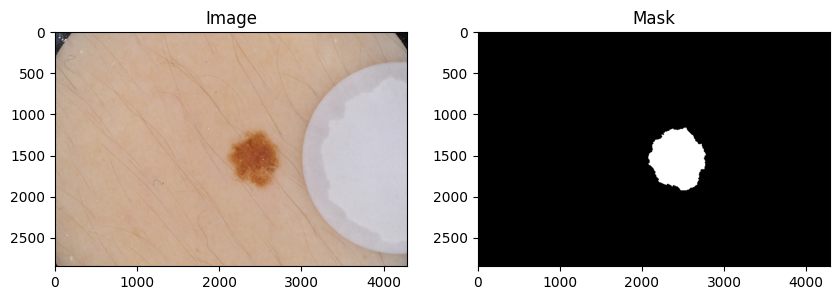

In [19]:
# import cv2
# import matplotlib as plt
# import random

# Choosing a Random image from the DataSet
sample_image_name = random.choice(image_files)

# path
sample_image_path = os.path.join(IMG_DIR, sample_image_name)
sample_mask_path = os.path.join(
    MASK_DIR, sample_image_name.replace(".jpg", "_Segmentation.png")
)

img = cv2.imread(sample_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
plt.title("Image")
plt.imshow(img)

plt.subplot(1, 2, 2)
plt.title("Mask")
plt.imshow(mask, cmap='gray')

plt.show()

In [20]:
# import numpy

vals, frequency = np.unique(mask, return_counts=True)
print(f"Unique Mask Values   :{vals}")
print(f"Count of Mask Values :{frequency}\n")

print(f"Shape of the IMAGE  :{img.shape}")

# DATASET FETCH AND CLEAN COMPLETE///

Unique Mask Values   :[  0 255]
Count of Mask Values :[11835324   376900]

Shape of the IMAGE  :(2848, 4288, 3)


### Verification

In [21]:
# Splitting Dataset into Training and Validation Set

# import torch.utils.data import random_split

DATASET = ISICDataset(IMG_DIR, MASK_DIR)

train_size = int(0.8 * len(DATASET))
val_size = len(DATASET) - train_size

train_dataset, val_dataset = random_split(DATASET, [train_size, val_size])

# Verify
print(f"Training Data SIZE   : {len(train_dataset)}")
print(f"Validation Data SIZE : {len(val_dataset)}")

Training Data SIZE   : 720
Validation Data SIZE : 180


In [22]:
# Creating data loaders for batch processing

# from torch.utils.data import DataLoader
""" 
which by default calls __getitem__ method and transformation applied
will be different for each cell
"""

train_loader = DataLoader(
    train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True
)  # 8 (image, mask) will be fed at a time. Shuffle = True for generalization. Batching is for stable gradient and speed
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
# Shuffle set to true -> generalization
# Batch Size of 8 (8 at a time), Stable Gradient and Speed...

##### Works and runs with NO ERRORS!